Descargar dataset

In [1]:
from PIL import Image
import os
import kagglehub
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from tqdm.auto import tqdm
import torch


/home/tuxenjoyer69/.local/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
path = kagglehub.dataset_download("mrigaankjaswal/capcha-images-to-training-data", output_dir="./dataset")
print("Path to dataset files:", path)

Path to dataset files: ./dataset


Crear una ED que pueda contenerlos y guardarlos

In [4]:
class CaptchaDataset(Dataset):
    def __init__(self, directory, files, transform=None):
        self.directory = directory
        self.transform = transform
        self.files = [
            file for file in files
            if file.endswith(".png")
        ]

        self.image = []
        
        for file in self.files:
            filename = file
            path = os.path.join(self.directory, filename)
            imagen = Image.open(path).convert("RGB")
            imagen = self.transform(imagen)
            self.image.append(imagen)

        target_not_normalizated = [ file.split(".")[-2] for file in self.files]

        chars = sorted(set("".join(target_not_normalizated)))
        self.char_to_idx = {char: i for i, char in enumerate(chars)}
        self.idx_to_char = {i: char for char, i in self.char_to_idx.items()}


        self.target = torch.tensor([
            [
                self.char_to_idx[caracter]
                for caracter in target_normalizated
            ] 
            for target_normalizated in target_not_normalizated
            ])
    def __len__(self):
        return len(self.files)

    def __getitem__(self, index):
        return self.image[index], self.target[index]

In [5]:
from sklearn.model_selection import train_test_split
files = [
    f
    for f in os.listdir("./dataset/generated")
    if f.endswith(".png")
]

train_files, test_files = train_test_split(
    files,
    test_size=0.2,
    random_state=42
)

train_files, val_files = train_test_split(
    files,
    test_size=0.2,
    random_state=42
)

transform = transforms.Compose([
    transforms.ToTensor()
])

train_dataset = CaptchaDataset(
    "./dataset/generated",
    train_files,
    transform=transform
)

test_dataset = CaptchaDataset(
    "./dataset/generated",
    test_files,
    transform=transform
)

val_dataset = CaptchaDataset(
    "./dataset/generated",
    val_files,
    transform=transform
)

train_dataloader = DataLoader(train_dataset, batch_size=200, shuffle=True, pin_memory=True)
test_dataloader = DataLoader(test_dataset, batch_size=200, shuffle=True, pin_memory=True)
val_dataloader = DataLoader(val_dataset, batch_size=200, shuffle=True, pin_memory=True)

In [6]:
import torch
import torch.nn as nn


class CaptchaCNN(nn.Module):
    def __init__(self, num_classes, captcha_length):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.LeakyReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.LeakyReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 64, 3, padding=1),
            nn.LeakyReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.LazyLinear(80),
            nn.LeakyReLU(),
            nn.Dropout(0.3),
            nn.Linear(80, captcha_length * num_classes)
        )

        self.num_classes = num_classes
        self.captcha_length = captcha_length

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)

        return x.view(
            -1,
            self.captcha_length,
            self.num_classes
        )

In [7]:
num_classes = len(train_dataset.char_to_idx)
captcha_length = train_dataset.target.shape[1]

print(num_classes)
print(captcha_length)

19
5


In [8]:
class Early_Stop():
  def __init__(self, patience=5, delta=0):
    self.patience = patience
    self.delta = delta
    self.best_val_loss = None
    self.no_val_improvement_times = 0
    self.stop = False

  def check_stop(self, val_loss):
    if self.best_val_loss is None or (val_loss + self.delta) < self.best_val_loss:
      self.best_val_loss = val_loss
      self.no_val_improvement_times = 0
    else:
      self.no_val_improvement_times += 1
      self.stop = self.no_val_improvement_times >= self.patience

def learning_loop(
    train_dataloader,
    val_dataloader,
    model,
    epochs,
    loss_fn,
    learning_rate,
    optimizer,
    device = "cuda",
    validation_freq=5
):
    epoch_loss_list = []
    epoch_char_acc_list = []
    epoch_captcha_acc_list = []
    val_epoch_loss_list = []
    val_epoch_char_acc_list = []
    val_epoch_captcha_acc_list = []
    val_epoch_list = []
    
    opt = optimizer(
        model.parameters(),
        lr=learning_rate
    )

    with tqdm(range(epochs), desc="Training") as pbar:

        for epoch in pbar:

            model.train()

            total_loss = 0.0
            total_chars = 0
            correct_chars = 0

            total_captchas = 0
            correct_captchas = 0

            for x_true, y_true in train_dataloader:

                x_true = x_true.to(device, non_blocking=True)
                y_true = y_true.to(device, non_blocking=True)

                # Forward
                y_pred = model(x_true)

                # Loss
                loss = loss_fn(
                    y_pred.reshape(-1, num_classes),
                    y_true.reshape(-1)
                )

                # Backward
                opt.zero_grad()
                loss.backward()
                opt.step()

                total_loss += loss.item()

                # Predicción
                predictions = torch.argmax(
                    y_pred,
                    dim=-1
                )

                # Accuracy por carácter
                correct_chars += (
                    predictions == y_true
                ).sum().item()

                total_chars += y_true.numel()

                # Accuracy por CAPTCHA completo
                captcha_correct = (
                    predictions == y_true
                ).all(dim=1)

                correct_captchas += captcha_correct.sum().item()
                total_captchas += y_true.size(0)

            # Métricas de la época
            epoch_loss = total_loss / len(train_dataloader)

            char_accuracy = (
                correct_chars / total_chars
            )

            captcha_accuracy = (
                correct_captchas / total_captchas
            )

            epoch_loss_list.append(epoch_loss)
            epoch_char_acc_list.append(char_accuracy)
            epoch_captcha_acc_list.append(captcha_accuracy)
            """
            pbar.set_postfix({
                "loss": f"{epoch_loss:.4f}",
                "char_acc": f"{char_accuracy:.2%}",
                "captcha_acc": f"{captcha_accuracy:.2%}"
            })
            """

            if epoch%validation_freq == 0:
                model.eval()
                val_total_loss = 0.0
                val_total_chars = 0
                val_correct_chars = 0

                val_total_captchas = 0
                val_correct_captchas = 0
                with torch.no_grad():
                    for x_val_true, y_val_true in val_dataloader:
                      
                        x_val_true = x_val_true.to(device, non_blocking=True)
                        y_val_true = y_val_true.to(device, non_blocking=True)

                        y_val_pred = model(x_val_true)
                        loss_val = loss_fn(y_val_pred.reshape(-1, num_classes), y_val_true.reshape(-1))

                        val_total_loss += loss_val.item()
                        val_predictions = torch.argmax(
                           y_val_pred,
                           dim=-1
                        )

                        # Accuracy por carácter
                        val_correct_chars += (
                            val_predictions == y_val_true
                        ).sum().item()

                        val_total_chars += y_val_true.numel()

                        # Accuracy por CAPTCHA completo
                        val_captcha_correct = (
                            val_predictions == y_val_true
                        ).all(dim=1)

                        val_correct_captchas += val_captcha_correct.sum().item()
                        val_total_captchas += y_val_true.size(0)

                    val_epoch_loss = val_total_loss / len(test_dataloader)

                    val_char_accuracy = (
                        val_correct_chars / val_total_chars
                    )

                    val_captcha_accuracy = (
                        val_correct_captchas / val_total_captchas
                    )

                    val_epoch_loss_list.append(val_epoch_loss)
                    val_epoch_char_acc_list.append(val_char_accuracy)
                    val_epoch_captcha_acc_list.append(val_captcha_accuracy)
                val_epoch_list.append(epoch + 1)
            pbar.set_postfix({
                "loss": f"{epoch_loss:.4f}",
                "char_acc": f"{char_accuracy:.2%}",
                "captcha_acc": f"{captcha_accuracy:.2%}",
                "val_loss": f"{val_epoch_loss:.4f}",
                "val_char_acc": f"{val_char_accuracy:.2%}",
                "val_captcha_acc": f"{val_captcha_accuracy:.2%}"
            })
            
    return (
        model,
        epoch_loss_list,
        epoch_char_acc_list,
        epoch_captcha_acc_list,
        val_epoch_loss_list,
        val_epoch_char_acc_list,
        val_epoch_captcha_acc_list,
        val_epoch_list
    )

In [9]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

model = CaptchaCNN(
    num_classes=num_classes,
    captcha_length=captcha_length
).to(device)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)
model, loss_history, char_acc_history, captcha_acc_history, val_loss_history, val_char_acc_history, val_captcha_acc_history, val_epoch_list = learning_loop(
    train_dataloader=train_dataloader,
    val_dataloader=val_dataloader,
    model=model,
    epochs=50,
    loss_fn=criterion,
    learning_rate=0.001,
    optimizer=torch.optim.Adam
)

Training: 100%|██████████| 50/50 [08:01<00:00,  9.64s/it, loss=0.3580, char_acc=87.68%, captcha_acc=56.25%, val_loss=1.7303, val_char_acc=58.60%, val_captcha_acc=6.81%]


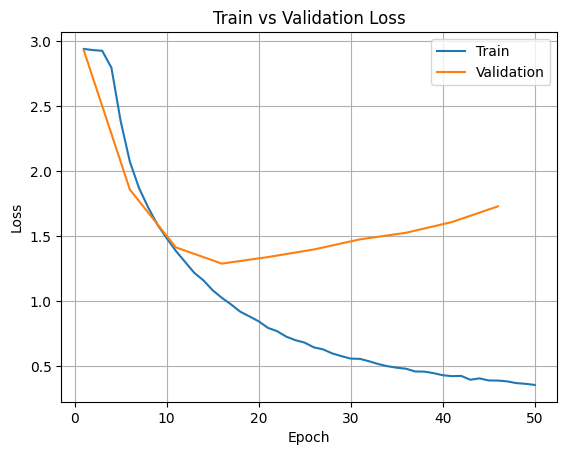

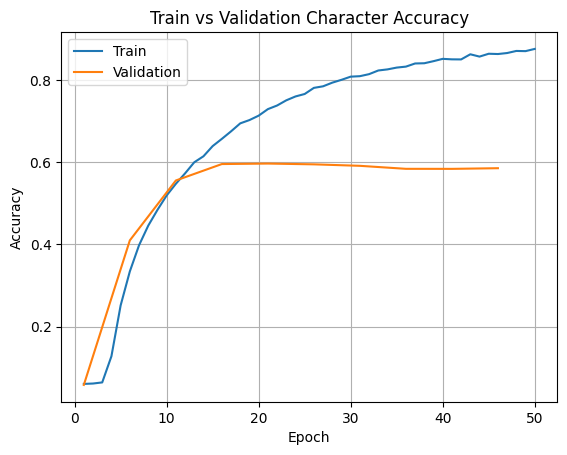

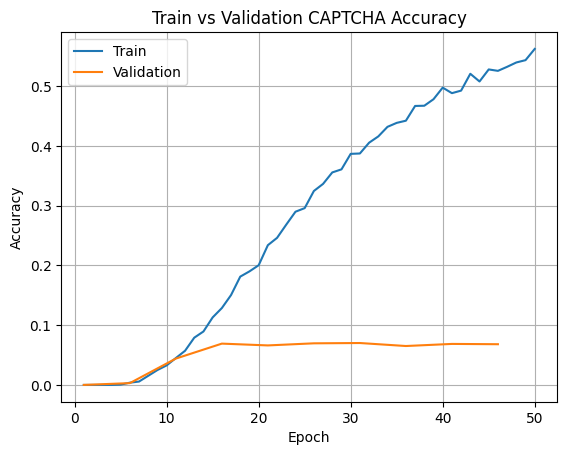

In [10]:
import matplotlib.pyplot as plt

epochs = range(1, len(loss_history) + 1)
# Loss
plt.figure()
plt.plot(epochs, loss_history, label="Train")
plt.plot(val_epoch_list, val_loss_history, label="Validation")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Train vs Validation Loss")
plt.legend()
plt.grid()
plt.show()


# Character accuracy
plt.figure()
plt.plot(epochs, char_acc_history, label="Train")
plt.plot(val_epoch_list, val_char_acc_history, label="Validation")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Train vs Validation Character Accuracy")
plt.legend()
plt.grid()
plt.show()


# CAPTCHA accuracy
plt.figure()
plt.plot(epochs, captcha_acc_history, label="Train")
plt.plot(val_epoch_list, val_captcha_acc_history, label="Validation")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Train vs Validation CAPTCHA Accuracy")
plt.legend()
plt.grid()
plt.show()

In [11]:
import pandas as pd
import torch

def predict_dataset(model, dataset, device):
    model.eval()

    results = []

    with torch.no_grad():

        for i in range(len(dataset)):

            image, target = dataset[i]

            image = image.unsqueeze(0).to(device)

            output = model(image)

            prediction = torch.argmax(output, dim=-1).squeeze(0)

            real = "".join(
                dataset.idx_to_char[idx.item()]
                for idx in target
            )

            predicted = "".join(
                dataset.idx_to_char[idx.item()]
                for idx in prediction
            )

            chars_correct = sum(
                a == b
                for a, b in zip(real, predicted)
            )

            results.append({
                "index": i,
                "file": dataset.files[i],
                "real": real,
                "prediction": predicted,
                "correct": real == predicted,
                "char_accuracy": chars_correct / len(real)
            })

    # DataFrame completo
    df = pd.DataFrame(results)

    # DataFrame resumen
    df_resume = pd.DataFrame({
        "samples": [len(df)],
        "captcha_accuracy": [df["correct"].mean()],
        "char_accuracy": [df["char_accuracy"].mean()],
        "captcha_correct": [df["correct"].sum()],
        "captcha_incorrect": [(~df["correct"]).sum()]
    })

    return df, df_resume

df, df_resume = predict_dataset(
    model,
    test_dataset,
    device
)

display(df_resume)
display(df)

,samples,captcha_accuracy,char_accuracy,captcha_correct,captcha_incorrect
0,1996,0.070641,0.581463,141,1855


,index,file,real,prediction,correct,char_accuracy
0,0,g7nfg.png,g7nfg,gnfge,False,0.2
1,1,58nxb.png,58nxb,5e8xb,False,0.6
2,2,y436x.png,y436x,y43xx,False,0.8
3,3,n67b5.png,n67b5,n67bb,False,0.8
4,4,fpbcb.png,fpbcb,pbbd2,False,0.2
...,...,...,...,...,...,...
1991,1991,23p4d.png,23p4d,3384f,False,0.4
1992,1992,mngmd.png,mngmd,n2ngb,False,0.0
1993,1993,p75p5.png,p75p5,p75p5,True,1.0
1994,1994,673gd.png,673gd,633gd,False,0.8


In [12]:
pd.set_option("display.max_rows", 100)
df

,index,file,real,prediction,correct,char_accuracy
0,0,g7nfg.png,g7nfg,gnfge,False,0.2
1,1,58nxb.png,58nxb,5e8xb,False,0.6
2,2,y436x.png,y436x,y43xx,False,0.8
3,3,n67b5.png,n67b5,n67bb,False,0.8
4,4,fpbcb.png,fpbcb,pbbd2,False,0.2
...,...,...,...,...,...,...
1991,1991,23p4d.png,23p4d,3384f,False,0.4
1992,1992,mngmd.png,mngmd,n2ngb,False,0.0
1993,1993,p75p5.png,p75p5,p75p5,True,1.0
1994,1994,673gd.png,673gd,633gd,False,0.8


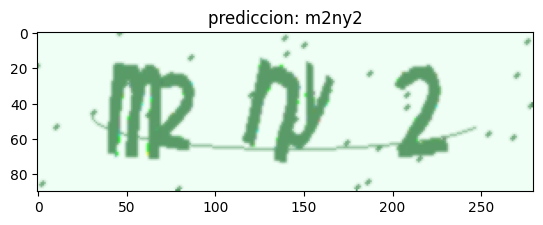

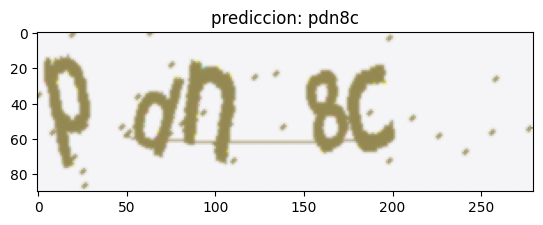

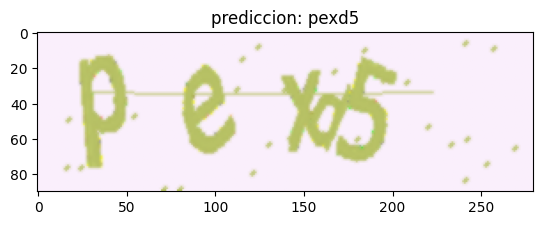

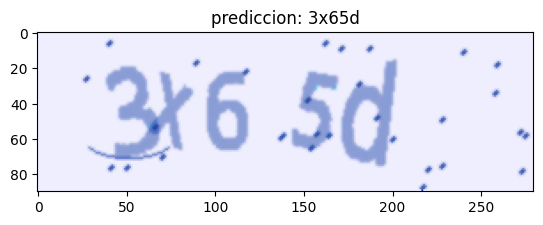

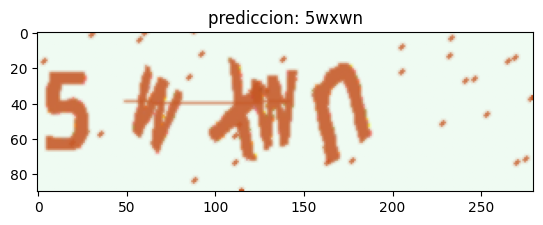

In [13]:
import matplotlib.pyplot as plt
for n_imagen in range(5):
    image, target = train_dataset[n_imagen]
    image = image.unsqueeze(0).to(device)
    output = model(image)
    prediction = torch.argmax(output, dim=-1).squeeze(0)
    predicted = "".join(
                train_dataset.idx_to_char[idx.item()]
                for idx in prediction
            )

    plt.imshow(train_dataset[n_imagen][0].cpu().permute(1,2,0))
    plt.title(f"prediccion: {predicted}")
    plt.show()

guardar modelo

In [14]:
torch.save(model.state_dict(), "captcha_model.pth")